# Notebook 01 – Computational Mathematics: checking the reference simulation

Every later step compares a fast model with a detailed simulation, the *reference*, run with the OPM Flow simulator. If the reference has an unmeasured numerical error, a learned model can look accurate when it is only copying that error. So I first check the reference, during injection and after it stops (*shut-in*).

The checks come from numerical verification: exact answers, grid refinement and a mass balance, each trusted only after it has caught a deliberate error. On a textbook pressure solution and a 1D front, they show that the boundary decides whether pressure falls after shut-in, and that a threshold plume edge converges far more slowly than the middle of the front.

This notebook covers WP1 of my research proposal (draft v0.6.3), which measures this error, `e_num`, for every predicted quantity. The checks on the real simulator are proposed future work.

**Labels used in this notebook**

- **My work:** my own earlier work in Computational Mathematics (implementations, exercises, analysis and explanations), summarised in §1.
- **Implemented example:** new code written for this notebook and run here on a textbook or toy problem, in a few seconds.
- **Proposed adaptation:** what I plan to do in the PhD; not done yet.
- **Evaluated result:** a tested research result. There are none yet.

## 1. My work in Computational Mathematics

*Label: My work (my own implementations, exercises and analysis).*

- **Verification hierarchy.** Checks of increasing strength: sanity checks, trends and conservation, benchmarks, comparison with another code, and exact or *manufactured* solutions (an exact solution chosen in advance, with a source term added to the equations so that it satisfies them).
- **Observed order of accuracy.** Refine the grid, plot the error against the cell size on log–log axes, and read the order from the slope. Order 1 means that halving the cell size halves the error.
- **Upwind and central schemes.** Upwind schemes take each value from the upstream side; they are stable but smear fronts (*numerical diffusion*). The cell Péclet number (advection against diffusion across one cell) and the CFL number (cells travelled per time step) control this.
- **Time stepping.** Euler and Runge–Kutta schemes, their order and their stability.
- **Linear algebra.** The singular value decomposition (SVD) and conditioning, which show how well a set of equations pins down its unknowns. They are used in Notebook 04.
- **Quadrature.** Numerical integration and its order. Here it is used to add up mass over cells.

My original notebooks are not reproduced in this repository.

## 2. From my work to the CO₂ problem

*Label: proposed adaptation.*

Each method from my work, what it becomes in WP1, and what has to change for CO₂ storage. A *decision quantity* is one of the pressures or plume measures the proposal predicts (P1–P4 and M1–M3, listed in the README).

| Method from my work | Use in WP1 | What has to change |
|---|---|---|
| Exact solutions as checks | Compare OPM Flow's pressure far from the plume with the Theis solution, and a closed-boundary run with a material balance (§3) | Two-phase CO₂ flow has no general exact solution, so exact checks only cover limiting cases |
| Conservation checks | A two-measure CO₂ inventory at every report step (§4.3) | Mass is split into mobile, immobile, dissolved and outflow parts, and density and porosity depend on pressure |
| Observed order and Richardson extrapolation | Grid refinement for each decision quantity, with a grid-convergence index or an error bracket (§4.2) | Quantities converge at different rates, and threshold-based plume measures may never reach the asymptotic range |
| Upwind schemes and the Péclet number | Explains why plume edges smear and converge slowly (§4) | In 2D and 3D, smearing interacts with gravity and capillary pressure |
| Time-stepping order and stability | Time-step refinement; rollout tests of the surrogate (Notebook 03) | The simulator adapts its time step, and shut-in must fall on a report step |
| Seeded defects | Each check must first catch a deliberate error (§4.3) | Defects chosen for CO₂ storage: a small mass leak, a shut-in one report step late |

## 3. A known answer for pressure: build-up and fall-off

*Label: implemented example (single-phase textbook solution).*

How does the pressure around an injector rise during injection and fall after shut-in, and what controls the fall? For a well injecting at a constant rate into a uniform aquifer of infinite extent, the answer is known exactly: the Theis (1935) solution. Shut-in at time $t_s$ is handled by *superposition*: I add a second well at the same place with the opposite rate from $t_s$ onwards.

The Theis solution gives the overpressure (pressure above its initial value) at distance $r$ and time $t$:

$$\Delta p(r,t) = \frac{q\,\mu}{4\pi k h}\,E_1\!\left(\frac{r^2}{4Dt}\right), \qquad D = \frac{k}{\phi\,\mu\,c_t}$$

with injection rate $q$, brine viscosity $\mu$, permeability $k$, thickness $h$ and porosity $\phi$. $E_1$ is the exponential integral, and $D$ is the hydraulic diffusivity, which sets how fast a pressure change spreads.

In the example I change only the total compressibility $c_t$ of rock and brine. It sets the **storativity**, the amount of fluid the formation stores per unit rise in pressure, so the example shows what storativity does and does not control after shut-in. I also compare the open aquifer with a closed box, from which no fluid can leave.

Note: this is single-phase flow. In the PhD it checks OPM Flow's pressure far from the plume, where mainly brine moves. It is not a solution for CO₂.

In [1]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import exp1
from scipy.optimize import brentq

In [2]:
# Reservoir and well values: round numbers, not a real site
yr = 365.25 * 24 * 3600    # seconds in one year
k = 2e-13                  # permeability, m2 (about 200 mD)
h = 50.0                   # reservoir thickness, m
phi = 0.3                  # porosity
mu = 5e-4                  # brine viscosity, Pa s
q = 0.045                  # injection rate at reservoir conditions, m3/s (about 1 Mt of CO2 per year at 700 kg/m3)
t_s = 10 * yr              # shut-in after 10 years
r = 1000.0                 # monitoring well 1 km from the injector

print(f'pressure scale q*mu/(4*pi*k*h) = {q * mu / (4 * np.pi * k * h) / 1e6:.3f} MPa')

pressure scale q*mu/(4*pi*k*h) = 0.179 MPa


In [3]:
def theis_shut_in(t, ct):
    # Overpressure (Pa) at distance r: injection from 0 to t_s, shut-in afterwards
    t = np.atleast_1d(np.asarray(t, dtype=float))
    D = k / (phi * mu * ct)                                   # hydraulic diffusivity, m2/s
    scale = q * mu / (4 * np.pi * k * h)
    dp = scale * exp1(r**2 / (4 * D * t))
    after = t > t_s
    dp[after] -= scale * exp1(r**2 / (4 * D * (t[after] - t_s)))   # the opposite well from t_s
    return dp

In [4]:
# Calculating the pressure at shut-in, the time for it to halve, and a closed-box comparison
ct_values = [2.5e-10, 1e-9, 4e-9]          # total compressibility, 1/Pa
pore_volume = np.pi * 10000.0**2 * h * phi  # closed cylinder of radius 10 km

for ct in ct_values:
    dp_s = theis_shut_in(t_s, ct)[0]
    # time after shut-in when the overpressure has fallen to half of dp_s
    tau = brentq(lambda s: theis_shut_in(t_s + s, ct)[0] - 0.5 * dp_s, 1.0, 20 * yr)
    # closed box: the injected volume has nowhere to go, so the average overpressure stays
    dp_box = q * t_s / (pore_volume * ct)
    print(f'ct = {ct:.1e} 1/Pa: dp at shut-in = {dp_s / 1e6:.2f} MPa, '
          f'halves {tau / 86400:.0f} days after shut-in, closed-box average = {dp_box / 1e6:.2f} MPa')

ct = 2.5e-10 1/Pa: dp at shut-in = 1.47 MPa, halves 60 days after shut-in, closed-box average = 12.05 MPa
ct = 1.0e-09 1/Pa: dp at shut-in = 1.23 MPa, halves 121 days after shut-in, closed-box average = 3.01 MPa
ct = 4.0e-09 1/Pa: dp at shut-in = 0.98 MPa, halves 245 days after shut-in, closed-box average = 0.75 MPa


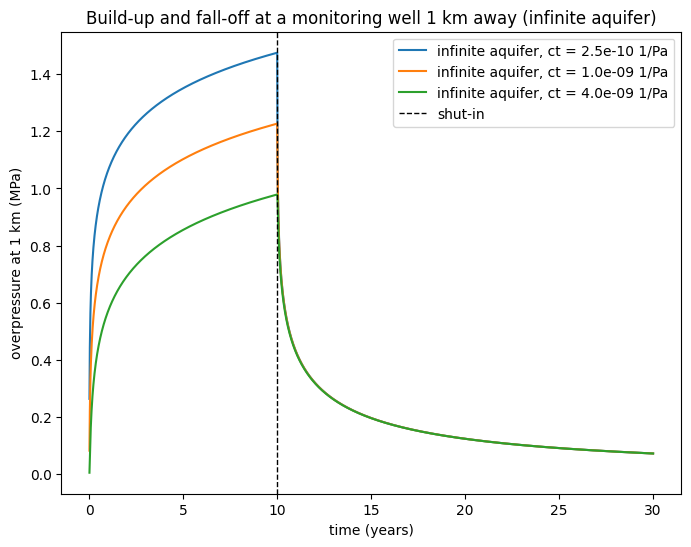

In [5]:
# Plot the pressure history at the monitoring well
t = np.linspace(0.01, 30, 3000) * yr

plt.figure(figsize=(8, 6))
for ct in ct_values:
    plt.plot(t / yr, theis_shut_in(t, ct) / 1e6, label=f'infinite aquifer, ct = {ct:.1e} 1/Pa')
plt.axvline(t_s / yr, color='k', ls='--', lw=1, label='shut-in')
plt.xlabel('time (years)')
plt.ylabel('overpressure at 1 km (MPa)')
plt.title('Build-up and fall-off at a monitoring well 1 km away (infinite aquifer)')
plt.legend();

In [6]:
# Late fall-off check: 20 years after shut-in the curves meet the Horner line, which has no ct in it
dt_after = 20 * yr
horner = q * mu / (4 * np.pi * k * h) * np.log((t_s + dt_after) / dt_after)
for ct in ct_values:
    print(f'ct = {ct:.1e} 1/Pa: overpressure 20 years after shut-in = {theis_shut_in(t_s + dt_after, ct)[0] / 1e6:.4f} MPa '
          f'(Horner line {horner / 1e6:.4f} MPa)')

ct = 2.5e-10 1/Pa: overpressure 20 years after shut-in = 0.0726 MPa (Horner line 0.0726 MPa)
ct = 1.0e-09 1/Pa: overpressure 20 years after shut-in = 0.0726 MPa (Horner line 0.0726 MPa)
ct = 4.0e-09 1/Pa: overpressure 20 years after shut-in = 0.0725 MPa (Horner line 0.0726 MPa)


#### How to read this result:

- During injection the overpressure at 1 km is higher when compressibility is lower: with less storage, pressure must rise more to make room for the same volume.
- After shut-in the three curves fall onto one curve. Once the start of the transient has passed, the fall-off in an infinite aquifer is set by permeability, thickness and viscosity, not by storativity. This is the Horner result of well testing, checked in the last cell above: late in the fall-off the overpressure is close to $\frac{q\mu}{4\pi k h}\ln\frac{t_s + \Delta t}{\Delta t}$, where $\Delta t$ is the time since shut-in, and $c_t$ does not appear. The half-decay times differ (60, 121 and 245 days) mainly because the curves start from different levels.
- In a closed box the average overpressure does not fall after shut-in at all. It stays at the injected volume divided by the pore volume times $c_t$ (a *material balance*): 3.0 MPa for $c_t = 10^{-9}$ 1/Pa, about forty times the open-aquifer value 20 years after shut-in. Here storativity sets the level directly.
- So the boundary type decides whether pressure falls after shut-in, and storativity and permeability decide how high it is and how it falls. An incompressible model cannot represent any of this, which is what limited the vertical-equilibrium study in my preliminary work (vertical equilibrium assumes that CO₂ and brine have already separated vertically; proposal §9).

These effects control the pressure quantities P2–P4 of the proposal: the average overpressure at and after shut-in, the overpressure below the caprock and at a distant point, and the time for overpressure to halve.

### 3.1 How this becomes a check in WP1

*Label: proposed adaptation.*

Run OPM Flow on a single-phase version of the reference grid and compare its pressure with the Theis solution at several distances, before and after shut-in, against a tolerance fixed in advance. For a closed-boundary run, compare the average overpressure after shut-in with the material balance. The same two formulas also serve as physics baselines in WP2.

## 4. Why plume edges converge slowly, and a mass-balance check

*Label: implemented example (1D model problem).*

When the grid is refined, which predicted quantities settle quickly and which do not? And does the scheme conserve mass? To see this on a problem with a known answer, I use a front that moves at speed $v$ and spreads by diffusion $D$ (*advection–diffusion*), as a stand-in for the edge of a CO₂ plume; in my earlier work I implemented central and upwind schemes for this problem.

The scheme here is a *finite-volume* scheme: the domain is divided into cells, and mass moves only through the faces between them, with upwind advection, central diffusion and explicit time steps. It is conservative, so mass is only changed by fluxes through the two ends of the domain.

I follow two measures of where the front is:

- the position where $c = 0.5$, which behaves like a mid-point or an integrated measure;
- the position where $c = 0.02$, which behaves like a plume edge defined by a small saturation threshold, as the footprint M2 and the migration distance M3 are in the proposal.

For a step in a long domain the exact solution is

$$c(x,t) = \tfrac{1}{2}\,\mathrm{erfc}\!\left(\frac{x - x_0 - vt}{2\sqrt{Dt}}\right),$$

where erfc is the complementary error function.

In [7]:
from scipy.special import erfcinv

# Problem values (dimensionless)
v, D, t_end, x0, L = 1.0, 1e-3, 0.5, 0.5, 2.0

def solve(N, inflow_factor=1.0):
    # Upwind advection + central diffusion on N cells; returns the final profile and the mass terms
    dx = L / N
    x = (np.arange(N) + 0.5) * dx
    left = np.arange(N) * dx
    c = np.clip((x0 - left) / dx, 0, 1)                 # exact cell averages of the initial step
    dt = 0.5 / (v / dx + 2 * D / dx**2)                 # stable explicit time step
    n = int(np.ceil(t_end / dt)); dt = t_end / n
    mass0 = c.sum() * dx
    scheduled_in, out = 0.0, 0.0
    for _ in range(n):
        cg = np.concatenate(([1.0], c, [c[-1]]))         # ghost cells: inflow c = 1, zero-gradient outflow
        F = v * cg[:-1] - D * (cg[1:] - cg[:-1]) / dx    # flux through every cell face
        F[0] = inflow_factor * F[0]                      # seeded defect when inflow_factor is not 1
        c = c - dt / dx * (F[1:] - F[:-1])
        scheduled_in += dt * v * 1.0                     # what the schedule says came in
        out += dt * F[-1]                                # what left through the far end
    return x, c, mass0, scheduled_in, out

def crossing(x, c, threshold):
    # Last position where the profile drops below the threshold (linear interpolation)
    i = np.where((c[:-1] >= threshold) & (c[1:] < threshold))[0][-1]
    return x[i] + (c[i] - threshold) * (x[i + 1] - x[i]) / (c[i] - c[i + 1])

x50_exact = x0 + v * t_end
x02_exact = x0 + v * t_end + 2 * np.sqrt(D * t_end) * erfcinv(2 * 0.02)
print(f'exact positions: c = 0.5 at x = {x50_exact:.4f}, c = 0.02 at x = {x02_exact:.4f}')

exact positions: c = 0.5 at x = 1.0000, c = 0.02 at x = 1.0649


### 4.1 Grid refinement

The same problem is solved on six grids, from 50 to 1600 cells; each grid halves the cell size of the one before.

In [8]:
# Step 1: solve on six grids and measure the error of both front positions
Ns = [50, 100, 200, 400, 800, 1600]
err50, err02, x02_num, gap = [], [], [], []
for N in Ns:
    x, c, m0, inj, out = solve(N)
    err50.append(abs(crossing(x, c, 0.5) - x50_exact))
    x02_num.append(crossing(x, c, 0.02))
    err02.append(abs(x02_num[-1] - x02_exact))
    gap.append(abs(c.sum() * L / N - (m0 + inj - out)) / inj)   # mass-balance gap, used in 4.3
    print(f'N = {N:5d}: error at c = 0.5 {err50[-1]:.1e}, error at c = 0.02 {err02[-1]:.1e}')

# Step 2: observed order between neighbouring grids (the grid spacing halves each time)
for i in range(len(Ns) - 1):
    p50 = np.log(err50[i] / err50[i + 1]) / np.log(2)
    p02 = np.log(err02[i] / err02[i + 1]) / np.log(2)
    print(f'{Ns[i]:5d} -> {Ns[i + 1]:5d}: observed order at c = 0.5 {p50:5.2f}, at c = 0.02 {p02:5.2f}')

N =    50: error at c = 0.5 2.9e-04, error at c = 0.02 1.6e-01
N =   100: error at c = 0.5 4.3e-04, error at c = 0.02 9.9e-02
N =   200: error at c = 0.5 3.2e-04, error at c = 0.02 6.3e-02
N =   400: error at c = 0.5 2.0e-04, error at c = 0.02 3.9e-02
N =   800: error at c = 0.5 9.5e-05, error at c = 0.02 2.4e-02
N =  1600: error at c = 0.5 3.7e-05, error at c = 0.02 1.5e-02
   50 ->   100: observed order at c = 0.5 -0.56, at c = 0.02  0.69
  100 ->   200: observed order at c = 0.5  0.43, at c = 0.02  0.66
  200 ->   400: observed order at c = 0.5  0.72, at c = 0.02  0.67
  400 ->   800: observed order at c = 0.5  1.05, at c = 0.02  0.69
  800 ->  1600: observed order at c = 0.5  1.36, at c = 0.02  0.74


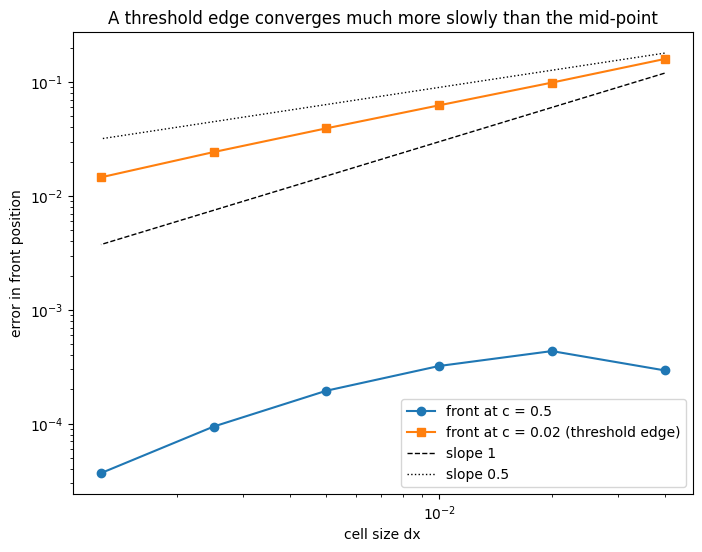

In [9]:
# Plot the error against cell size, with reference slopes
dx = L / np.array(Ns)

plt.figure(figsize=(8, 6))
plt.loglog(dx, err50, 'o-', label='front at c = 0.5')
plt.loglog(dx, err02, 's-', label='front at c = 0.02 (threshold edge)')
plt.loglog(dx, 3 * dx, 'k--', lw=1, label='slope 1')
plt.loglog(dx, 0.9 * dx**0.5, 'k:', lw=1, label='slope 0.5')
plt.xlabel('cell size dx')
plt.ylabel('error in front position')
plt.title('A threshold edge converges much more slowly than the mid-point')
plt.legend();

#### How to read this result:

- The position where $c = 0.5$ is almost exact on every grid (errors below 0.001). Upwind smearing is nearly symmetric about the mid-point, and its observed order jumps around because the error is so small.
- The position where $c = 0.02$ is off by 0.16 on the coarsest grid and still by 0.015 on the finest. Its observed order is about 0.7, not the 1 expected for an upwind scheme: numerical diffusion widens the front, and a low threshold sits in the widened tail.

This is the pattern that hypothesis H1 of the proposal expects in the real problem: pressure and mass converge well, but threshold plume geometry (the footprint M2 and the migration distance M3) does not. So in WP1 each decision quantity gets its own refinement check.

### 4.2 Estimating the converged answer without knowing it

In the PhD there is no exact answer, only a sequence of grids. From three grids (fine $f_1$, medium $f_2$, coarse $f_3$, refinement ratio 2) I can estimate:

- the observed order $p$;
- a *Richardson* estimate of the converged value, which extrapolates the three results to zero cell size;
- Roache's (1994) grid-convergence index (GCI), an uncertainty band on the fine-grid value.

In [10]:
# Richardson extrapolation and GCI from three grids, compared with the exact answer
Fs = 1.25    # safety factor for three-grid studies
for i in range(len(Ns) - 2):
    f3, f2, f1 = x02_num[i], x02_num[i + 1], x02_num[i + 2]      # coarse, medium, fine
    p = np.log(abs(f3 - f2) / abs(f2 - f1)) / np.log(2)
    f_rich = f1 + (f1 - f2) / (2**p - 1)
    gci = Fs * abs(f1 - f2) / (2**p - 1)                           # absolute band on the fine value
    inside = abs(f1 - x02_exact) <= gci
    print(f'grids {Ns[i]}/{Ns[i + 1]}/{Ns[i + 2]}: p = {p:.2f}, Richardson error {abs(f_rich - x02_exact):.1e}, '
          f'fine-grid error {abs(f1 - x02_exact):.1e}, GCI band {gci:.1e}, exact inside band: {inside}')

grids 50/100/200: p = 0.73, Richardson error 7.6e-03, fine-grid error 6.3e-02, GCI band 6.9e-02, exact inside band: True
grids 100/200/400: p = 0.65, Richardson error 1.9e-03, fine-grid error 3.9e-02, GCI band 5.2e-02, exact inside band: True
grids 200/400/800: p = 0.64, Richardson error 2.7e-03, fine-grid error 2.4e-02, GCI band 3.4e-02, exact inside band: True
grids 400/800/1600: p = 0.62, Richardson error 3.4e-03, fine-grid error 1.5e-02, GCI band 2.3e-02, exact inside band: True


#### How to read this result:

- Richardson extrapolation cuts the error by between four and twenty times, and the GCI band contains the exact answer on every triplet.
- But the observed order (about 0.6–0.7) is far from the scheme's formal order, so the grids may not be in the *asymptotic range*, where the error shrinks at the formal rate and the extrapolation can be trusted.

In WP1 I would therefore report such a quantity with an error bracket, not with the extrapolated value, and say so in the error budget.

### 4.3 Two-measure mass balance and a seeded defect

The same run gives the stored mass in two independent ways:

1. add up the mass in all cells (quadrature over the grid);
2. start with the initial mass, add what the schedule says came in, and subtract what left through the far boundary.

With a conservative scheme they agree to round-off. To check that the check works, I seed a defect: the inflow flux is made 0.2 % too small, as a small leak would be.

In [11]:
# Calculating the mass-balance gap without and with a seeded defect
print('relative gap, correct code :', ', '.join(f'{g:.0e}' for g in gap))

x, c, m0, inj, out = solve(400, inflow_factor=0.998)
defect_gap = abs(c.sum() * L / 400 - (m0 + inj - out)) / inj
print(f'relative gap, seeded 0.2 % inflow defect (N = 400): {defect_gap:.1e}')

tolerance = 1e-6    # the kind of pre-set tolerance used in WP1
print(f'defect caught with tolerance {tolerance:.0e}: {defect_gap > tolerance}')

relative gap, correct code : 7e-16, 0e+00, 4e-16, 2e-15, 2e-16, 1e-14
relative gap, seeded 0.2 % inflow defect (N = 400): 1.7e-03
defect caught with tolerance 1e-06: True


#### How to read this result:

- Without the defect the two measures agree to about $10^{-14}$ or better. With a 0.2 % inflow error the gap is about $2\times10^{-3}$, far above round-off, so a tolerance of $10^{-6}$ catches it.

In WP1 the same idea compares OPM Flow's CO₂ inventory outputs with the four terms recomputed from saved fields: mobile, immobile, dissolved, and outflow across the edge of the model (proposal §5). The outflow term here plays the role of $M_\text{out}$: it is computed from the boundary flux, not assumed to be zero.

## 5. How WP1 will be evaluated

*Label: proposed adaptation. Values in square brackets are set with the supervisor before any results exist.*

The checks of §§3–4 become pass rules for the real simulator:

| Check | Quantity | Pass rule |
|---|---|---|
| Theis comparison (single-phase run) | Overpressure at [3] distances, before and after shut-in | Within [2 %] |
| Closed-box material balance | Average overpressure after shut-in | Within [1 %] |
| Second code (MRST or JutulDarcy) | P1–P4 and M1–M3 on [3] cases | Differences reported against the geological spread `u_geo` |
| Two-measure CO₂ inventory | Sum of the four terms against injected mass, every report step | Relative gap below [1e-6]; runs with outflow above [0.1 %] of injected mass flagged |
| Grid and time-step refinement | Every decision quantity | Observed order and GCI where it converges, otherwise an error bracket |
| Seeded defects | A [0.1 %] mass leak; shut-in one report step late | Every check above catches its defect before it is used |

The output of WP1 is the reference's numerical error `e_num = R_h − R∞` (the result on the production grid, used for the whole ensemble, minus a refined reference) and the model-form differences `e_mf` (between model levels and physics options), for each quantity, before and after shut-in (proposal §7).

## 6. Assumptions and what has to change

- Exact solutions only cover limiting cases (single phase; 1D transport). The CO₂ problem is two-phase with gravity, capillary pressure and dissolution, so exact checks test parts of the code, not the whole.
- The order of about 0.7 belongs to this scheme and threshold. In 2D and 3D with gravity, each quantity can converge at a different rate, and the rates can differ before and after shut-in.
- Richardson extrapolation assumes the grids are in the asymptotic range. Where the observed order is far from the formal order, a bracket is safer.
- The refined reference `R∞`, an estimate of the converged solution of the model equations, comes from a refinement subset of [20] realisations, so `e_num` is measured only there. These are test realisations, never used to train the surrogate, so its error against `R∞` is measured on cases it has not seen. For the other realisations `e_num` is estimated from the subset. That estimate is an error indicator, not a bound: it is checked on [5] more refined realisations kept apart for the purpose, and anything that rests on it is reported as provisional (proposal §7).
- The same holds under changed conditions. A firm accuracy verdict for another shut-in time, rate schedule or boundary (the shifted cases of Notebook 02 §5) needs refined cases of that shift. If only baseline cases are refined, every verdict under a shift stays provisional. How many shifted cases can be refined is a computing-budget choice that is still open.
- The pressure example uses round numbers. Site values would come from the Smeaheia and Sleipner data (proposal §5).

## 7. Status

**Run here:** the implemented examples of §§3–4, on a textbook solution and a 1D model problem. **Proposed for the PhD:** the WP1 checks of §5 on OPM Flow. **My work:** summarised in §1. **Research results:** none yet.

## References and further reading

- Nordbotten, J. M., Fernø, M. A., Flemisch, B., Kovscek, A. R. & Lie, K.-A. (2024). The 11th Society of Petroleum Engineers Comparative Solution Project: problem definition. *SPE Journal* 29(05), 2507–2524. (Definitions of mobile, immobile and dissolved CO₂.)
- Ogata, A. & Banks, R. B. (1961). A solution of the differential equation of longitudinal dispersion in porous media. U.S. Geological Survey Professional Paper 411-A. (The column version of the advection–dispersion solution.)
- Roache, P. J. (1994). Perspective: a method for uniform reporting of grid refinement studies. *Journal of Fluids Engineering* 116(3), 405–413.
- Theis, C. V. (1935). The relation between the lowering of the piezometric surface and the rate and duration of discharge of a well using ground-water storage. *Transactions, American Geophysical Union* 16(2), 519–524.